# Exercise 2.5 (programming)

Design and conduct an experiment to demonstrate the difficulties that sample-average methods have for nonstationary problems.
Use a modified version of the 10-armed testbed in which all the q*(a) start out equal and then take independent random walks **(say by adding a normally distributed increment with mean 0 and standard deviation 0.01 to all the q*(a) on each step).**


Prepare plots like Figure 2.2 for an action-value method using:
- sample averages
- incrementally computed
- another action-value method using a constant step-size parameter, alpha = 0.1.

Use eps = 0.1 and longer runs, say of 10,000 steps.

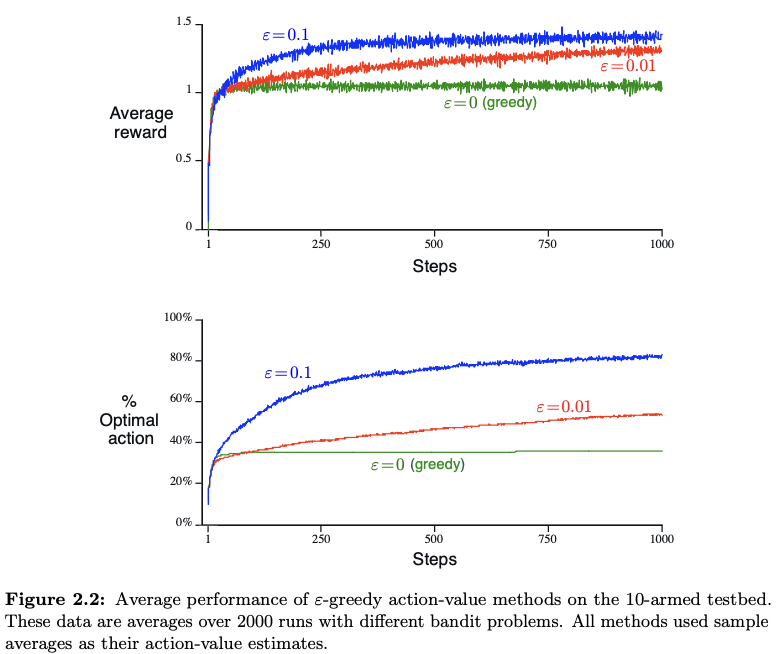
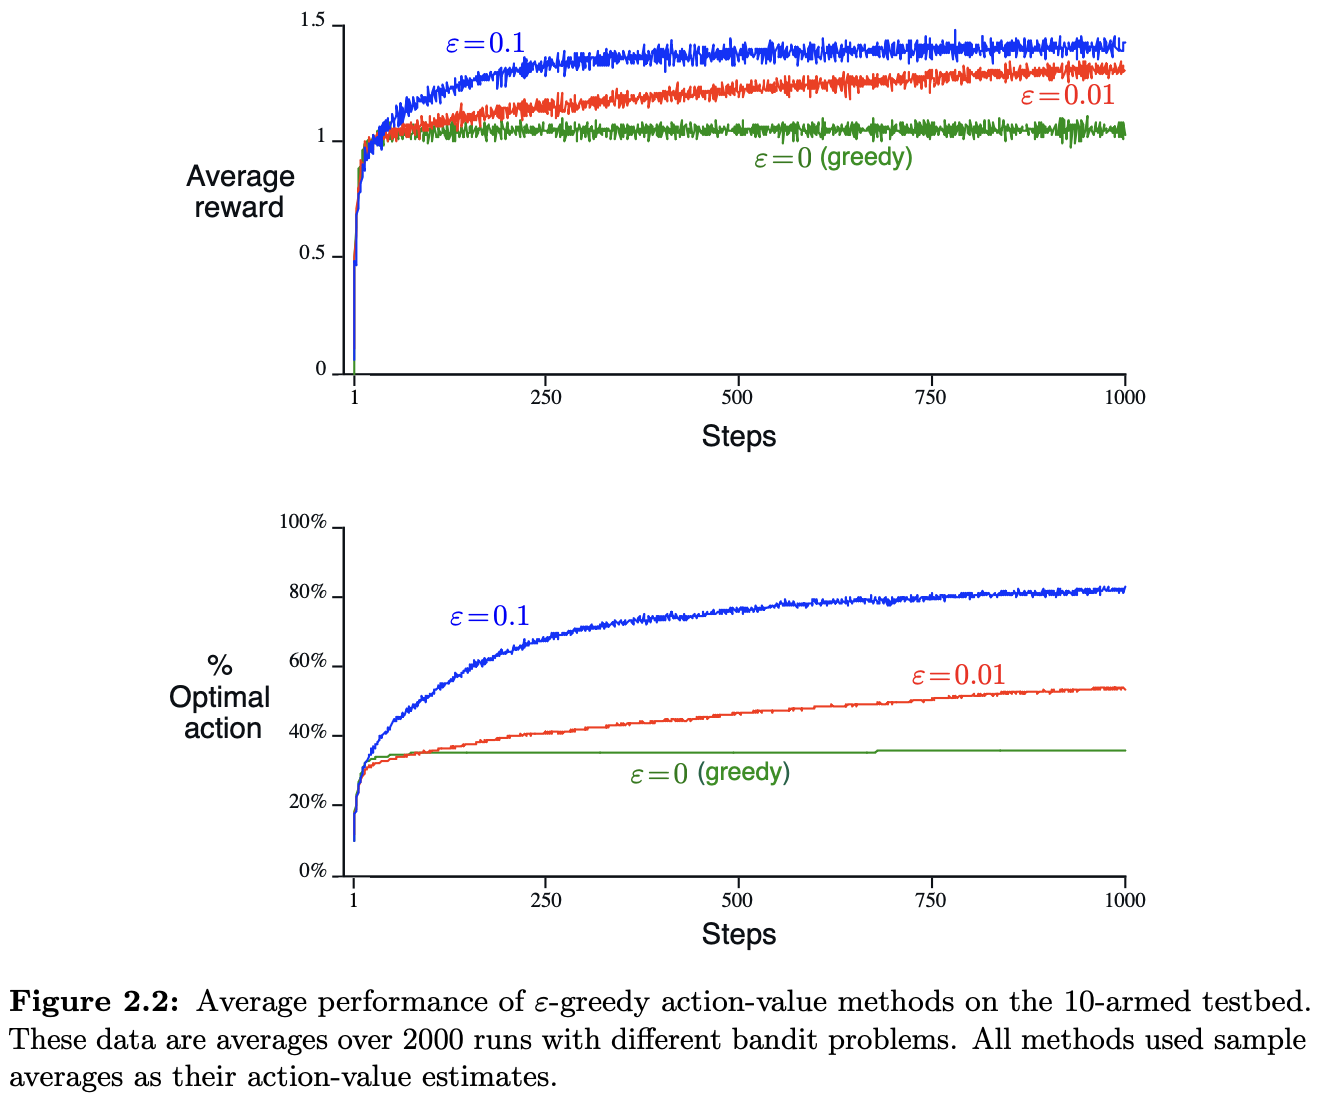
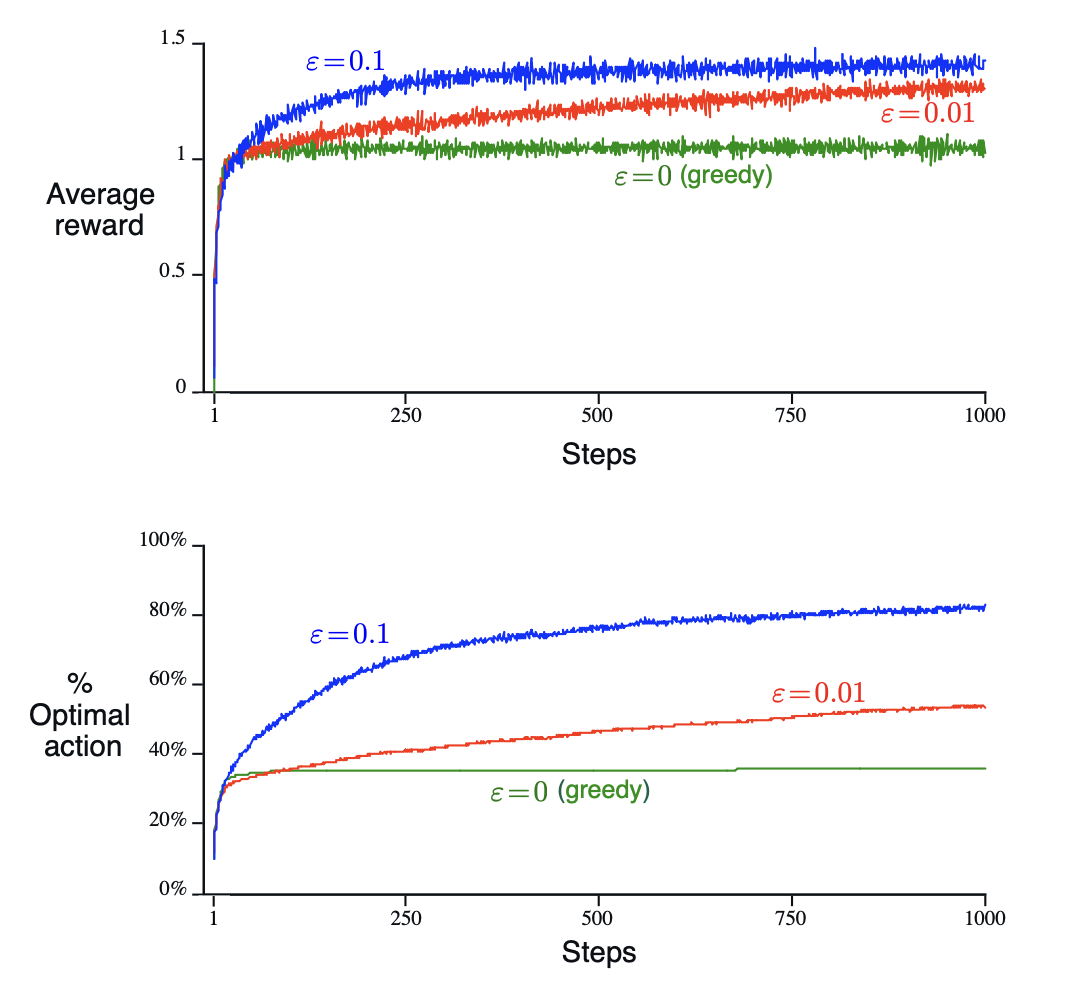

## Imports

In [ ]:
import numpy as np
from scipy import stats as sts
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

### Stationary

In [317]:
def bandit_alg(q_opt, eps, time_steps=1000, k=10):
    Q = np.zeros(shape=k) # estimated value of action
    N = np.zeros(shape=k) # number of times action was chosen
    
    opt_action = np.argmax(q_opt)
    
    reward_list = []
    opt_action_choice = []
    
    for _ in range(time_steps):
        val = np.random.uniform(0, 1)
        action = np.random.randint(0, k) if val < eps else np.argmax(Q)

        N[action] += 1
        reward = np.random.normal(q_opt[action], 1)
        
        Q[action] += (1 / N[action]) * (reward - Q[action])
        # Q[action] += alpha * (reward - Q[action])
        
        reward_list.append(reward)        
        opt_action_choice.append(1 if opt_action == action else 0)

    return reward_list, opt_action_choice

In [318]:
k = 10 # number of bandits
runs_number = 2000
time_steps = 5000
epsilon = [0., 0.01, 0.1]
avg_reward_list = [[], [], []]
opt_action_cnt_list = [[], [], []]

for j, eps in enumerate(epsilon):
    for i in tqdm(range(runs_number)):
        q_opt = np.random.normal(0, 1, k)
        reward_per_time, opt_action_choice = bandit_alg(q_opt, eps=eps, time_steps=time_steps, k=k)
        avg_reward_list[j].append(reward_per_time)
        opt_action_cnt_list[j].append(opt_action_choice)

100%|██████████| 2000/2000 [00:31<00:00, 63.73it/s]


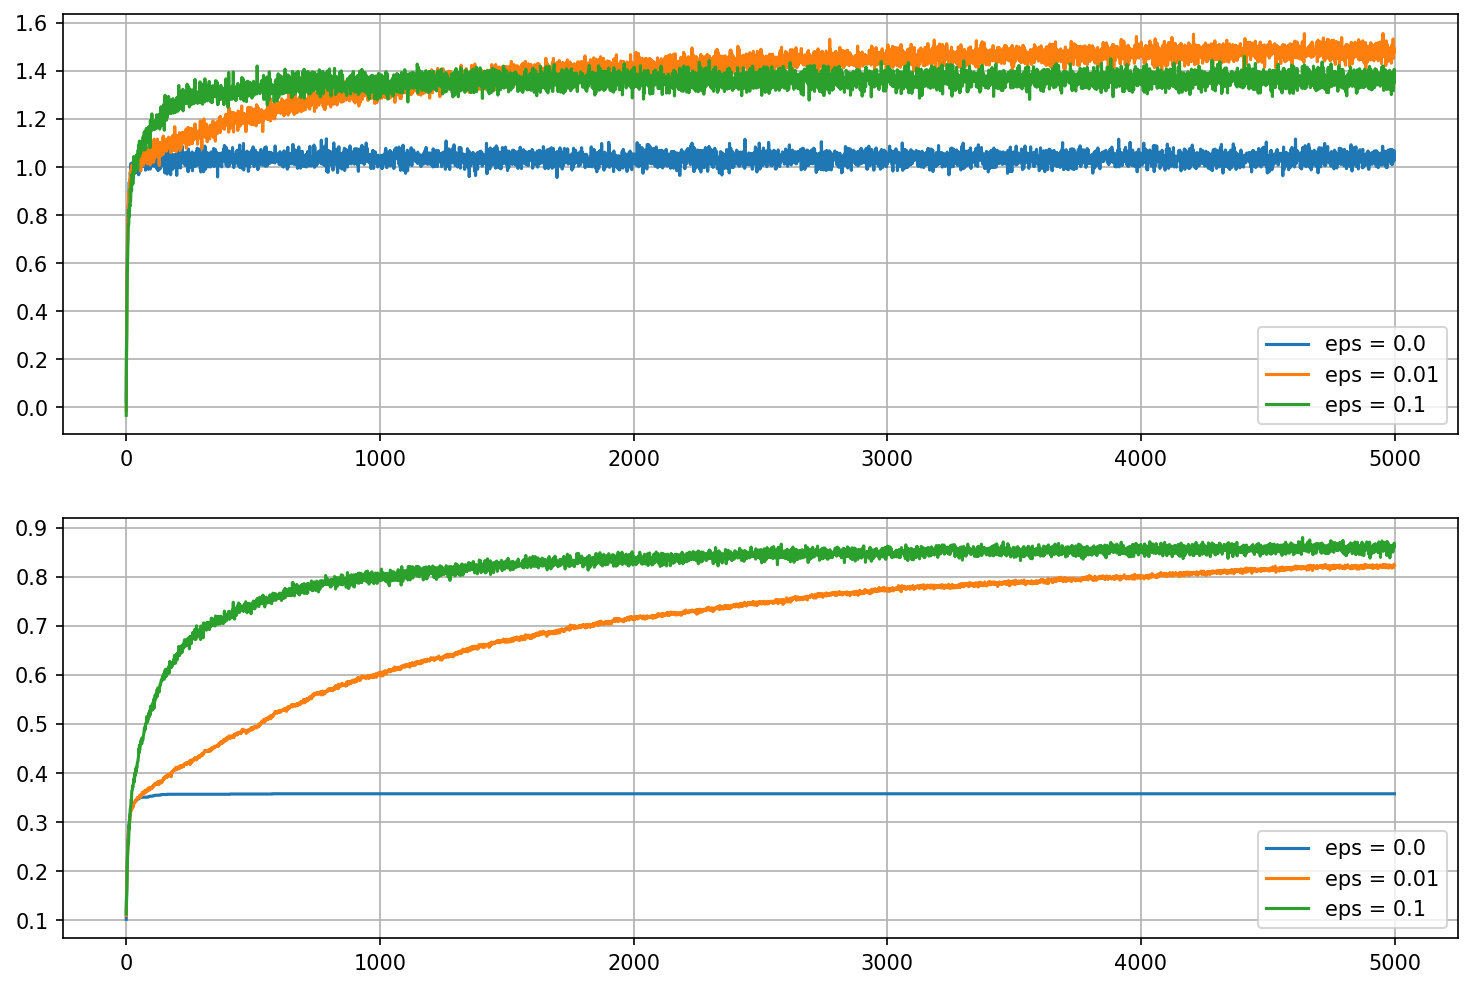

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
fig.dpi = 150
for i, e in enumerate(epsilon):
    sns.lineplot(x=np.arange(time_steps), y=np.array(avg_reward_list[i]).mean(axis=0), label=f"eps = {e}", ax=ax[0])
    sns.lineplot(x=np.arange(time_steps), y=np.array(opt_action_cnt_list[i]).mean(axis=0), label=f"eps = {e}", ax=ax[1])
ax[0].grid()
ax[1].grid()
ax[0].set_ylabel("Average reward")
ax[1].set_ylabel("% Optimal action")

- with stationary problem algorithm works as expected, after 1.2k of time steps algorithm with eps = 0.01 starts winning;

### Non-stationary

In [320]:
def bandit_alg_modified(q_opt, eps, time_steps=1000, k=10):
    Q = np.zeros(shape=k) # estimated value of action
    N = np.zeros(shape=k) # number of times action was chosen
    
    opt_action = np.argmax(q_opt)
    
    reward_list = []
    opt_action_choice = []
    
    for _ in range(time_steps):
        # =========================================
        # MODIFICATION
        q_opt += np.random.normal(0, 0.01, k)
        # =========================================
        val = np.random.uniform(0, 1)
        action = np.random.randint(0, k) if val < eps else np.argmax(Q)

        N[action] += 1
        reward = np.random.normal(q_opt[action], 1)
        
        Q[action] += (1 / N[action]) * (reward - Q[action])
        # Q[action] += alpha * (reward - Q[action])
        
        reward_list.append(reward)        
        opt_action_choice.append(1 if opt_action == action else 0)

    return reward_list, opt_action_choice

In [321]:
k = 10 # number of bandits
runs_number = 2000
time_steps = 5000
epsilon = [0., 0.01, 0.1]
avg_reward_list = [[], [], []]
opt_action_cnt_list = [[], [], []]

for j, eps in enumerate(epsilon):
    for i in tqdm(range(runs_number)):
        q_opt = np.zeros(k)
        reward_per_time, opt_action_choice = bandit_alg_modified(q_opt, eps=eps, time_steps=time_steps, k=k)
        avg_reward_list[j].append(reward_per_time)
        opt_action_cnt_list[j].append(opt_action_choice)

100%|██████████| 2000/2000 [00:38<00:00, 52.17it/s]


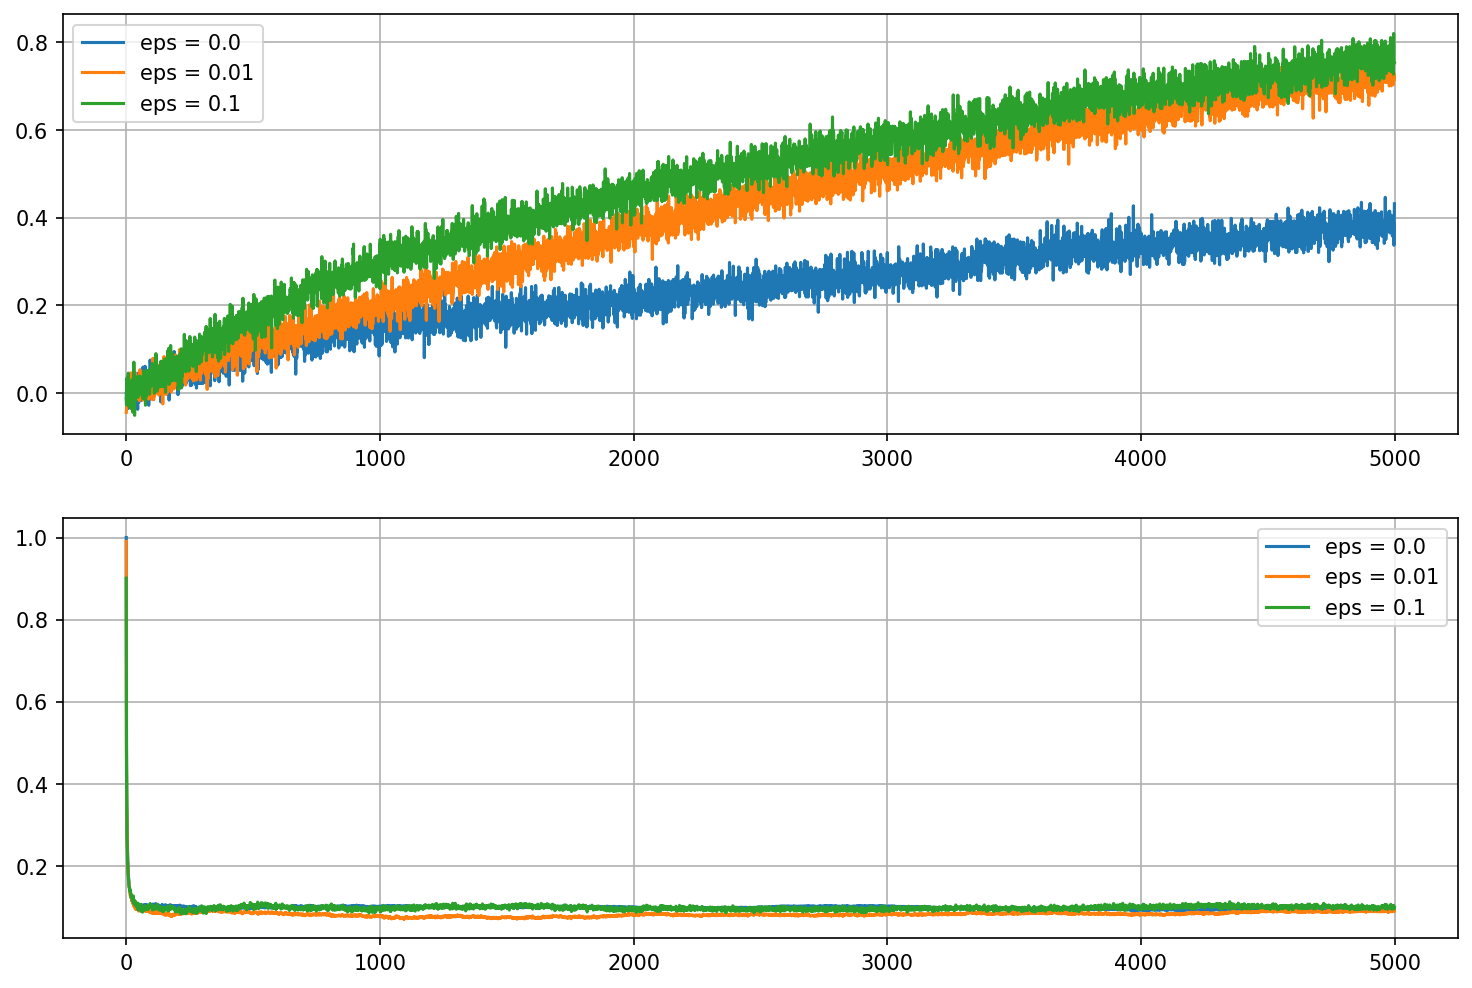

In [322]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
fig.dpi = 150
for i, e in enumerate(epsilon):
    sns.lineplot(x=np.arange(time_steps), y=np.array(avg_reward_list[i]).mean(axis=0), label=f"eps = {e}", ax=ax[0])
    sns.lineplot(x=np.arange(time_steps), y=np.array(opt_action_cnt_list[i]).mean(axis=0), label=f"eps = {e}", ax=ax[1])
ax[0].grid()
ax[1].grid()

- As it can be seen, algorithm doesn't work properly with non-stationary problem;
- As the best action always changes, algorithm always tries to find new one;